---
title: "Lab 1: Gapminder Data Visualization"
format:
  html:
    theme: vapor
    embed-resources: true
---

In [73]:
import pandas as pd
df_Q1 = pd.read_csv("Lab_1_Data/q1data.csv")
df_Q1.head()

,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


In [74]:
df_Q1.columns

Index(['income', 'life_exp', 'population', 'year', 'country', 'four_regions',
       'six_regions', 'eight_regions', 'world_bank_region'],
      dtype='object')

## Task 1

The aesthetics used in this graph are:

- x-axis: income
- y-axis: life expectancy
- size: population
- color/fill: world region

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


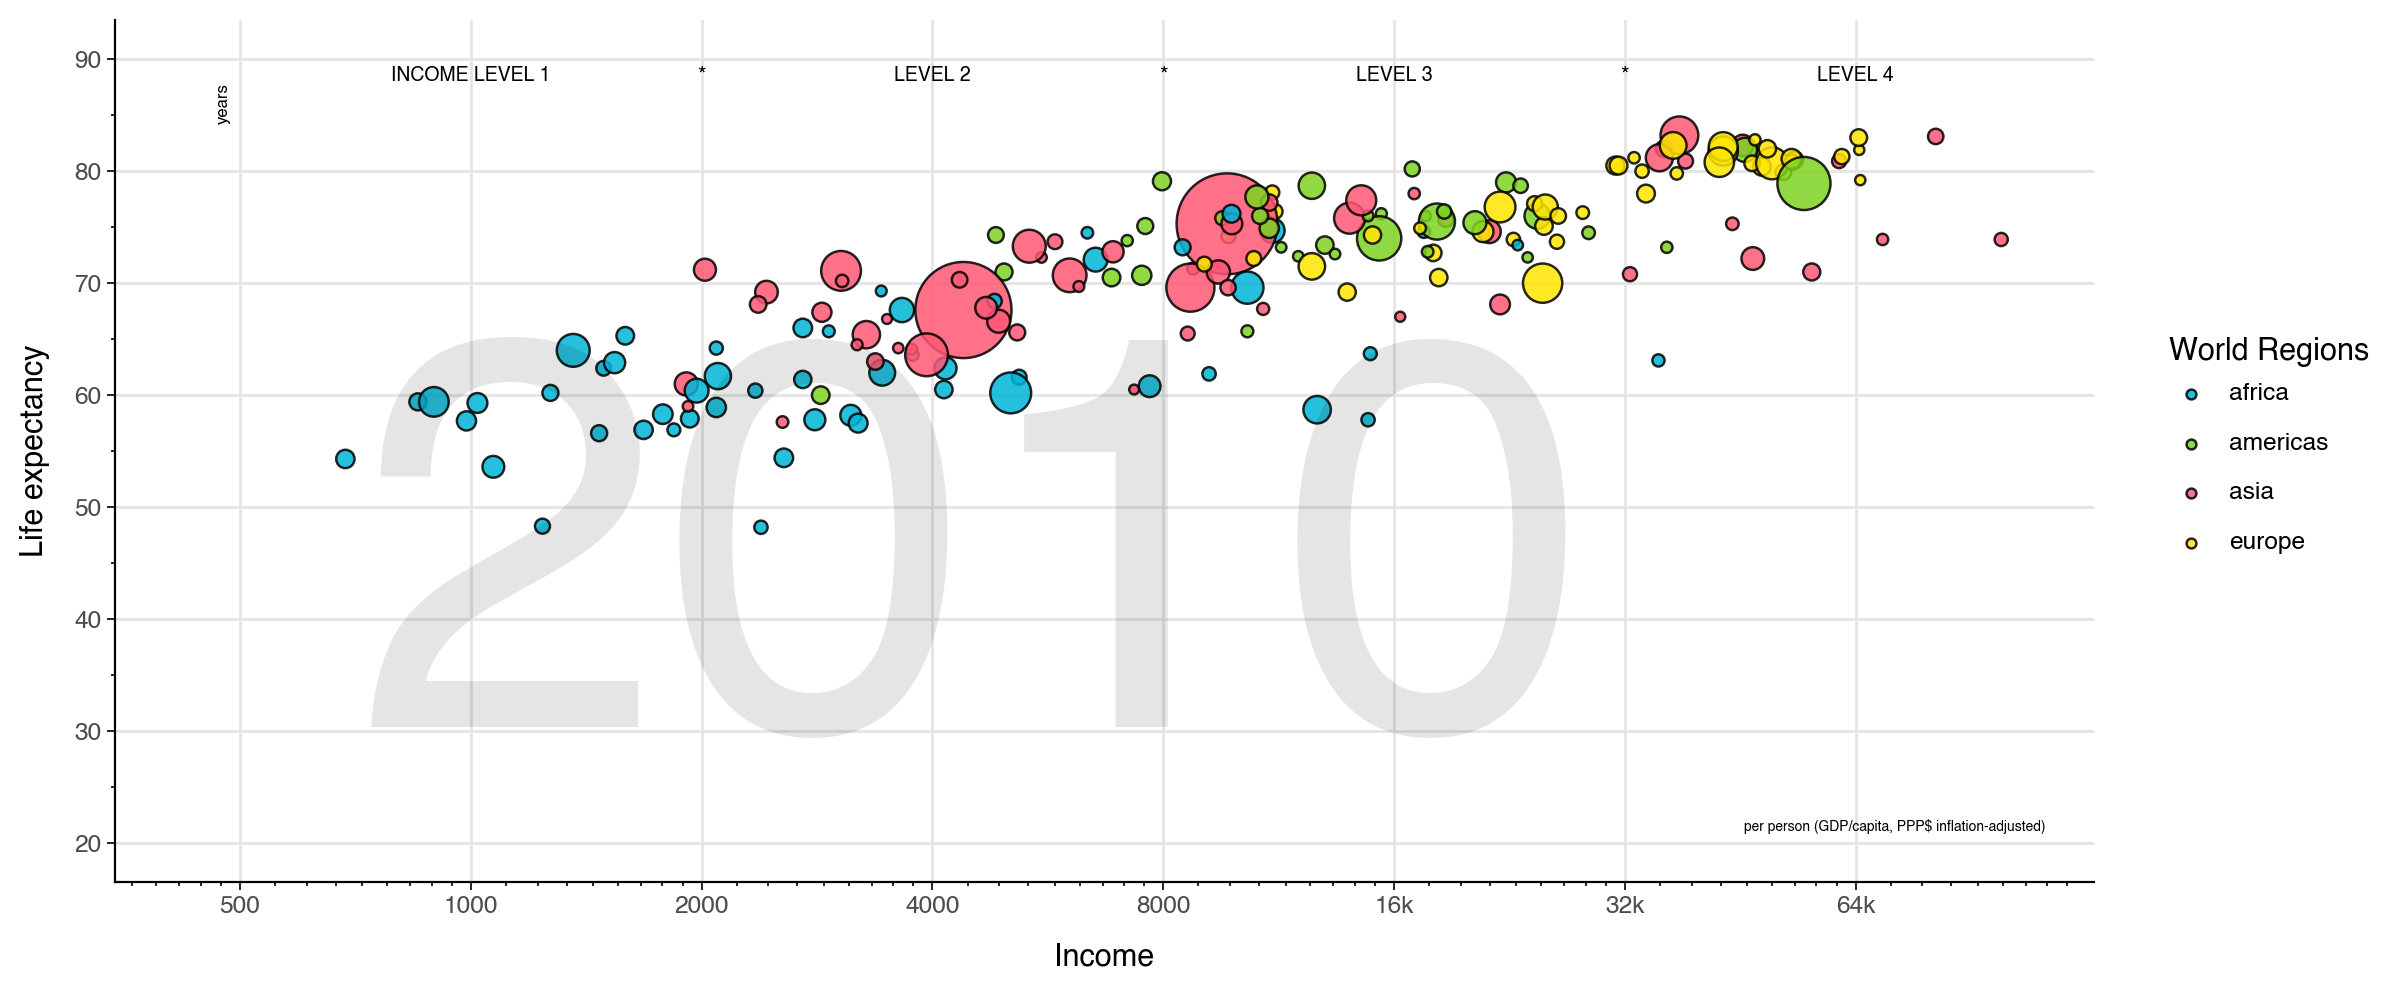

In [75]:
from plotnine import *

q1_plot = df_Q1.dropna(
    subset=["income", "life_exp", "population", "four_regions"]
).copy()


def income_labels(values):
    labels = []

    for value in values:
        if abs(value - 500) < 5:
            labels.append("500")
        elif abs(value - 1000) < 5:
            labels.append("1000")
        elif abs(value - 2000) < 5:
            labels.append("2000")
        elif abs(value - 4000) < 5:
            labels.append("4000")
        elif abs(value - 8000) < 5:
            labels.append("8000")
        elif abs(value - 16000) < 50:
            labels.append("16k")
        elif abs(value - 32000) < 50:
            labels.append("32k")
        elif abs(value - 64000) < 50:
            labels.append("64k")
        else:
            labels.append("")

    return labels


(
    ggplot(
        q1_plot,
        aes(
            x="income",
            y="life_exp",
            size="population",
            fill="four_regions"
        )
    )

    + geom_point(
        shape="o",
        color="black",
        stroke=0.5,
        alpha=0.85
    )

    + scale_x_log10(
        limits=(450, 100000),
        breaks=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000],
        labels=income_labels
    )

    + scale_y_continuous(
        limits=(20, 90),
        breaks=[20, 30, 40, 50, 60, 70, 80, 90]
    )

    + scale_fill_manual(
        name="World Regions",
        values={
            "africa": "#00B5D8",
            "americas": "#7ED321",
            "asia": "#FF5874",
            "europe": "#FFE600"
        }
    )

    + scale_size_continuous(
        range=(1.5, 20),
        guide=None
    )

    + annotate("text", x=1000, y=88.5, label="INCOME LEVEL 1", size=7)
    + annotate("text", x=4000, y=88.5, label="LEVEL 2", size=7)
    + annotate("text", x=16000, y=88.5, label="LEVEL 3", size=7)
    + annotate("text", x=64000, y=88.5, label="LEVEL 4", size=7)

    # Stars between income levels
    + annotate("text", x=2000, y=88.5, label="*", size=8)
    + annotate("text", x=8000, y=88.5, label="*", size=8)
    + annotate("text", x=32000, y=88.5, label="*", size=8)

    + annotate(
        "text",
        x=4500,
        y=43,
        label="2010",
        size=200,
        alpha=0.10
    )

    + annotate(
        "text",
        x=475,
        y=86,
        label="years",
        size=6,
        angle=90
    )

    + annotate(
        "text",
        x=72000,
        y=21.5,
        label="per person (GDP/capita, PPP$ inflation-adjusted)",
        size=5
    )

    + labs(
        x="Income",
        y="Life expectancy"
    )

    + theme_minimal()

    + theme(
        figure_size=(12, 5),

        panel_grid_minor=element_blank(),

        axis_line=element_line(
            color="black",
            size=0.8
        ),

        axis_ticks=element_line(
            color="black",
            size=0.6
        )
    )
)

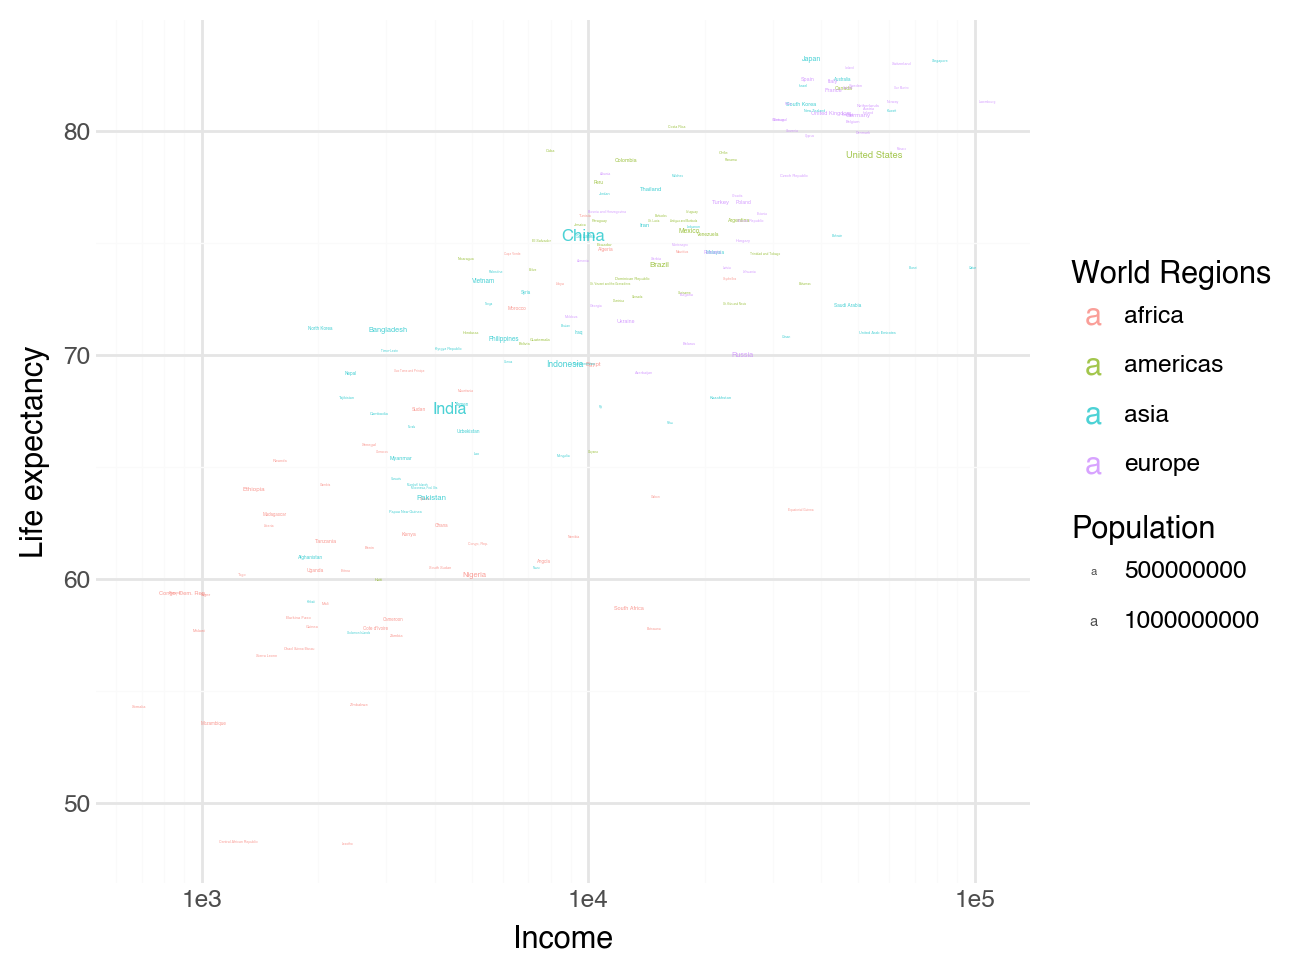

In [70]:
(
    ggplot(
        q1_plot,
        aes(
            x="income",
            y="life_exp",
            color="four_regions",
            size="population",
            label="country"
        )
    )
    + geom_text(alpha=0.7)
    + scale_x_log10()
    + labs(
        x="Income",
        y="Life expectancy",
        color="World Regions",
        size="Population"
    )
    + theme_minimal()
)

This alternative uses country names instead of points. It works because it still shows income, life expectancy, region, and population. However, it is harder to read because many country names overlap, so the bubble chart is a better choice for this data.

In [50]:
import pandas as pd
df_Q2 = pd.read_csv("Lab_1_Data/q2data.csv")
df_Q2.head()

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,NaN,NaN,NaN,1997,Afghanistan,asia,south_asia,asia_west,South Asia
1,36.7,11.5,427,1997,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,22.5,22.6,825,1997,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,NaN,NaN,1997,American Samoa,NaN,NaN,NaN,NaN
4,NaN,NaN,434,1997,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


In [51]:
df_Q2.columns

Index(['imports', 'exports', 'energy', 'year', 'country', 'four_regions',
       'six_regions', 'eight_regions', 'world_bank_region'],
      dtype='object')

In [55]:
df_Q2.dtypes

imports              float64
exports              float64
energy                object
year                   int64
country               object
four_regions          object
six_regions           object
eight_regions         object
world_bank_region     object
dtype: object

In [57]:
df_Q2["energy"] = pd.to_numeric(
    df_Q2["energy"],
    errors="coerce"
)

In [64]:
df_Q2["year"].unique()

array([1997])

## Task 2

The aesthetics used in this graph are:

- x-axis: exports
- y-axis: imports
- size: energy
- color/fill: world region

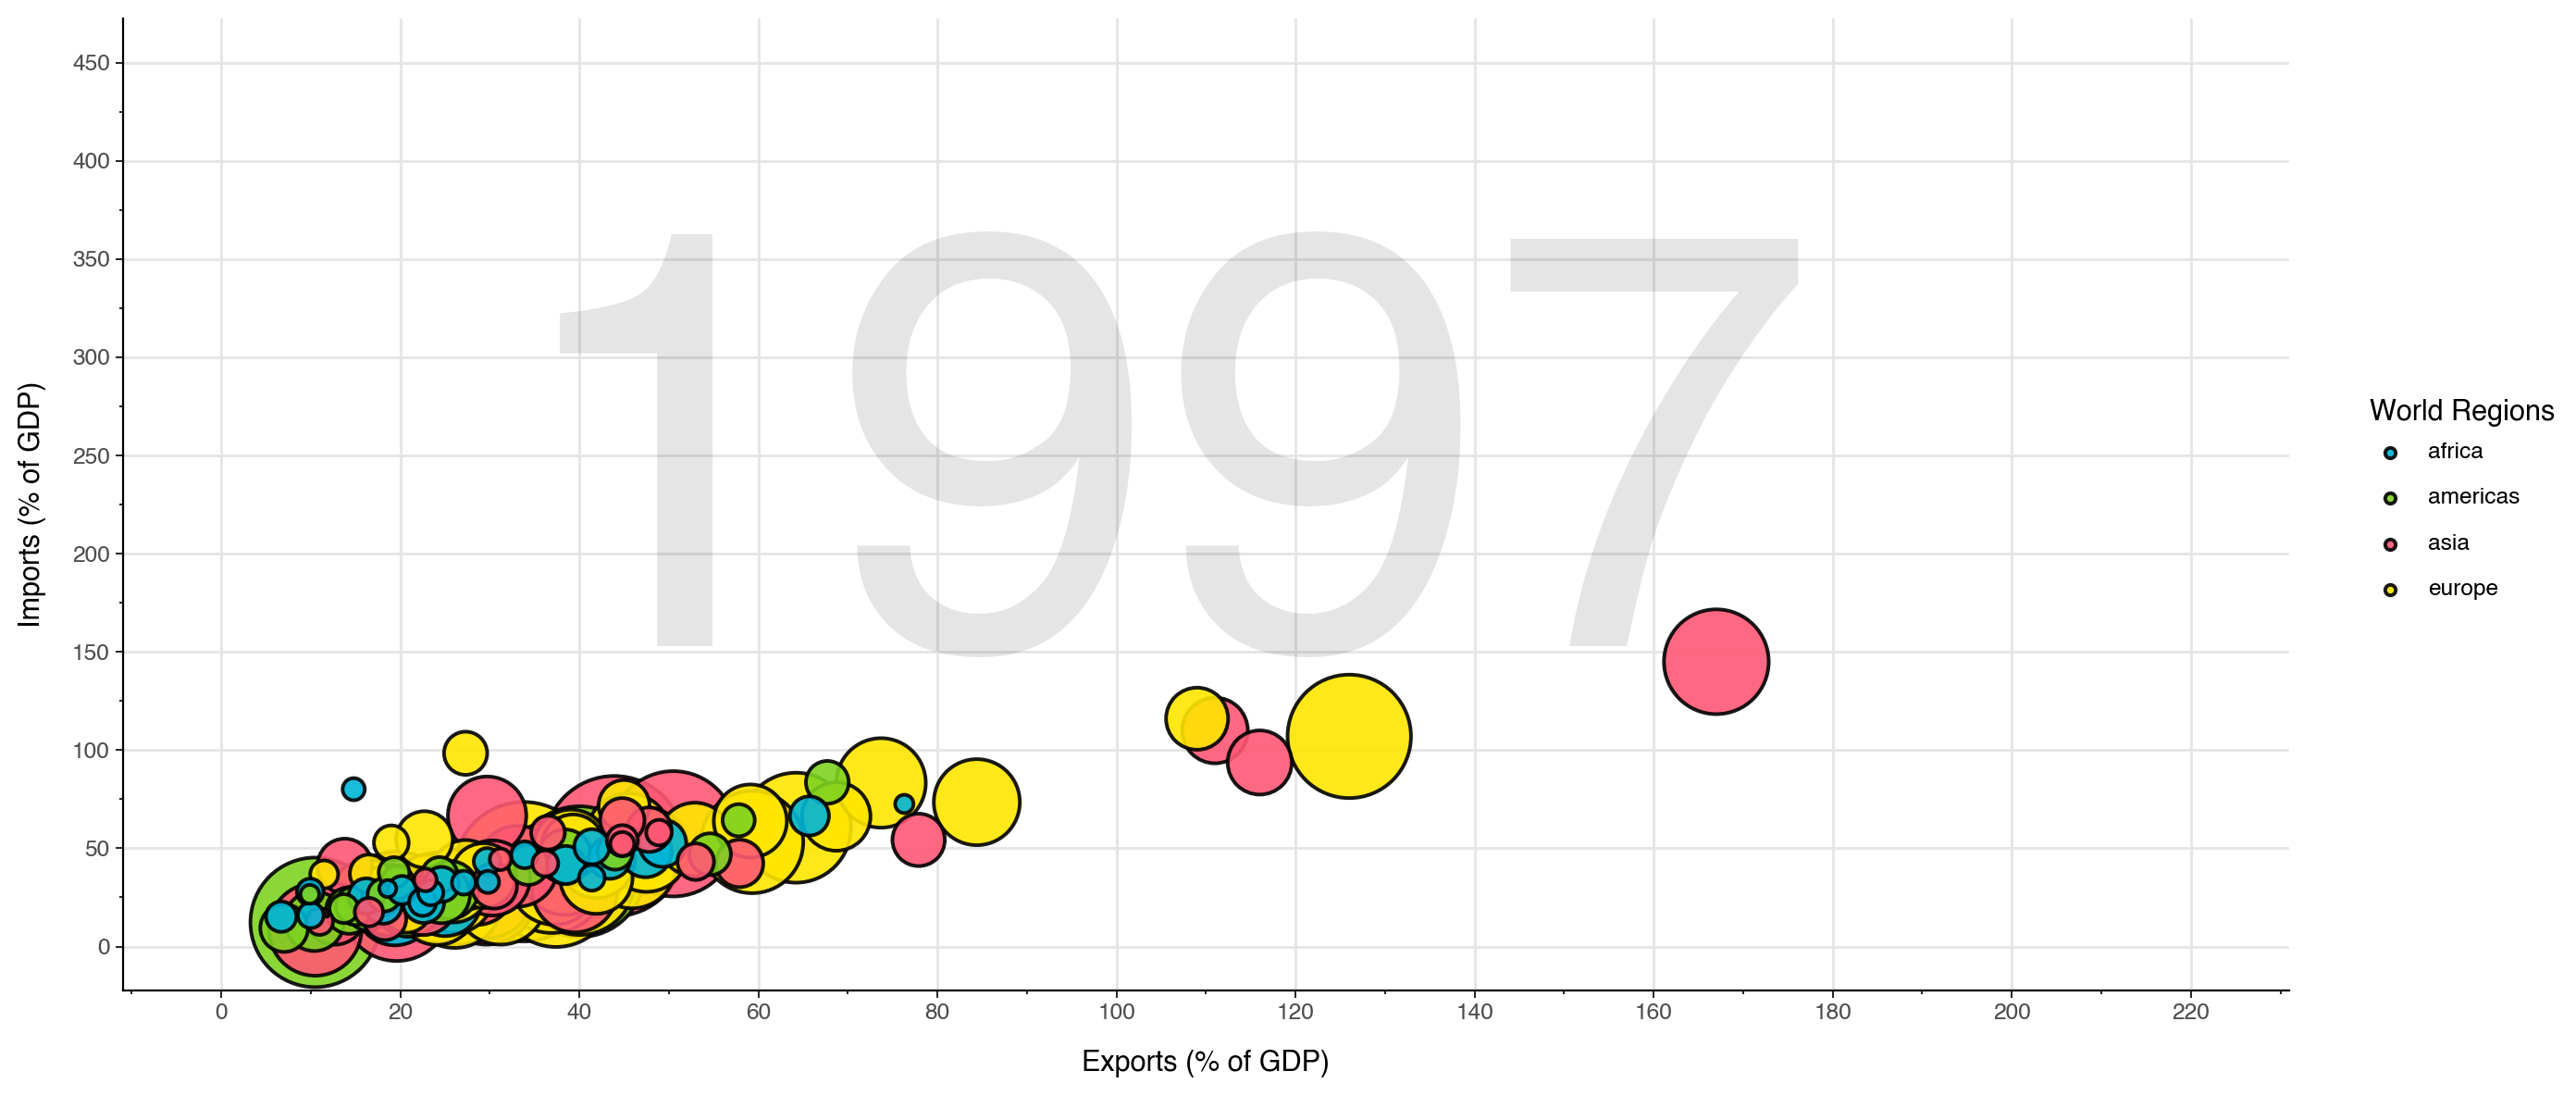

In [76]:
from plotnine import *

q2_plot = (
    df_Q2
    .dropna(subset=["exports", "imports", "energy", "four_regions"])
    .sort_values("energy", ascending=False)
    .copy()
)

(
    ggplot(
        q2_plot,
        aes(
            x="exports",
            y="imports",
            size="energy",
            fill="four_regions"
        )
    )

    + geom_point(
        shape="o",
        color="black",
        stroke=0.8,
        alpha=0.9
    )

    + scale_x_continuous(
        limits=(0, 220),
        breaks=[0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220]
    )

    + scale_y_continuous(
        limits=(0, 450),
        breaks=[0, 50, 100, 150, 200, 250, 300, 350, 400, 450]
    )

    + scale_fill_manual(
        name="World Regions",
        values={
            "africa": "#00B5D8",
            "americas": "#7ED321",
            "asia": "#FF5874",
            "europe": "#FFE600"
        }
    )

    + scale_size_area(
        max_size=30,
        guide=None
    )

    + annotate(
        "text",
        x=105,
        y=230,
        label="1997",
        size=230,
        alpha=0.10
    )

    + labs(
        x="Exports (% of GDP)",
        y="Imports (% of GDP)"
    )

    + theme_minimal()
    + theme(
        figure_size=(14, 6),
        panel_grid_minor=element_blank(),
        axis_line=element_line(
            color="black",
            size=0.8
        ),
        axis_ticks=element_line(
            color="black",
            size=0.6
        )
    )
)

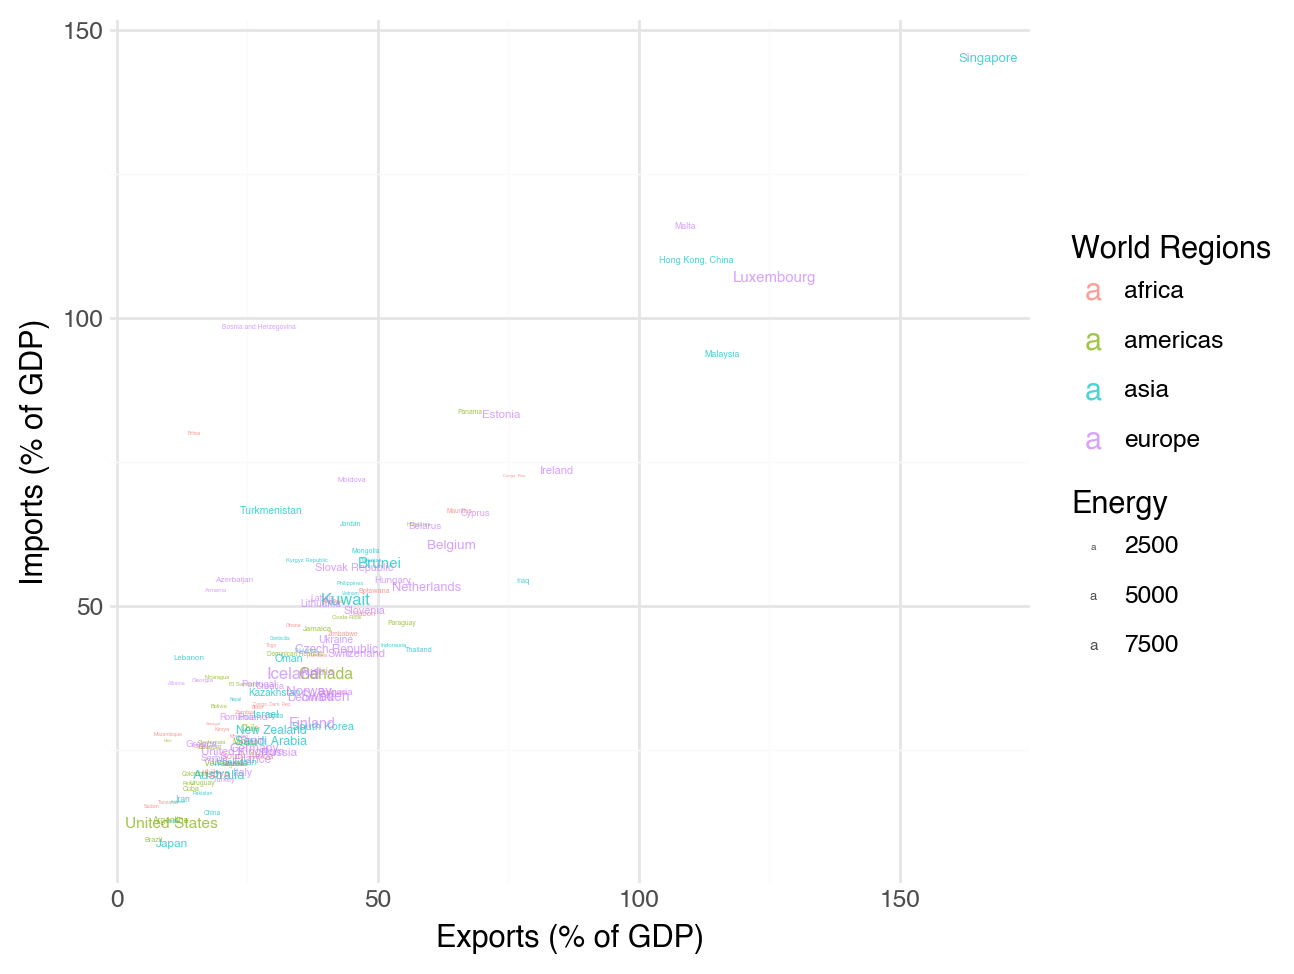

In [71]:
(
    ggplot(
        q2_plot,
        aes(
            x="exports",
            y="imports",
            color="four_regions",
            size="energy",
            label="country"
        )
    )
    + geom_text(alpha=0.7)
    + labs(
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        color="World Regions",
        size="Energy"
    )
    + theme_minimal()
)

This alternative uses country names instead of points. It still shows exports, imports, energy, and world region. However, many of the country names overlap because a lot of countries have similar export and import values. This makes the text plot harder to read, so the bubble chart is a better way to visualize this data.

In [65]:
import pandas as pd
df_Q3 = pd.read_csv("Lab_1_Data/q3data.csv")
df_Q3.head()

,internet_users,gdp,income,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,0.00456,330.0,1190.0,2001,Afghanistan,asia,south_asia,asia_west,South Asia
1,0.39000,2570.0,6780.0,2001,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,1.59000,3770.0,9230.0,2001,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,10500.0,NaN,2001,American Samoa,NaN,NaN,NaN,NaN
4,11.30000,42600.0,35600.0,2001,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia


In [66]:
df_Q3.columns

Index(['internet_users', 'gdp', 'income', 'year', 'country', 'four_regions',
       'six_regions', 'eight_regions', 'world_bank_region'],
      dtype='object')

## Task 3

The aesthetics used in this graph are:

- x-axis: internet users
- y-axis: GDP per capita
- size: income
- color/fill: world region

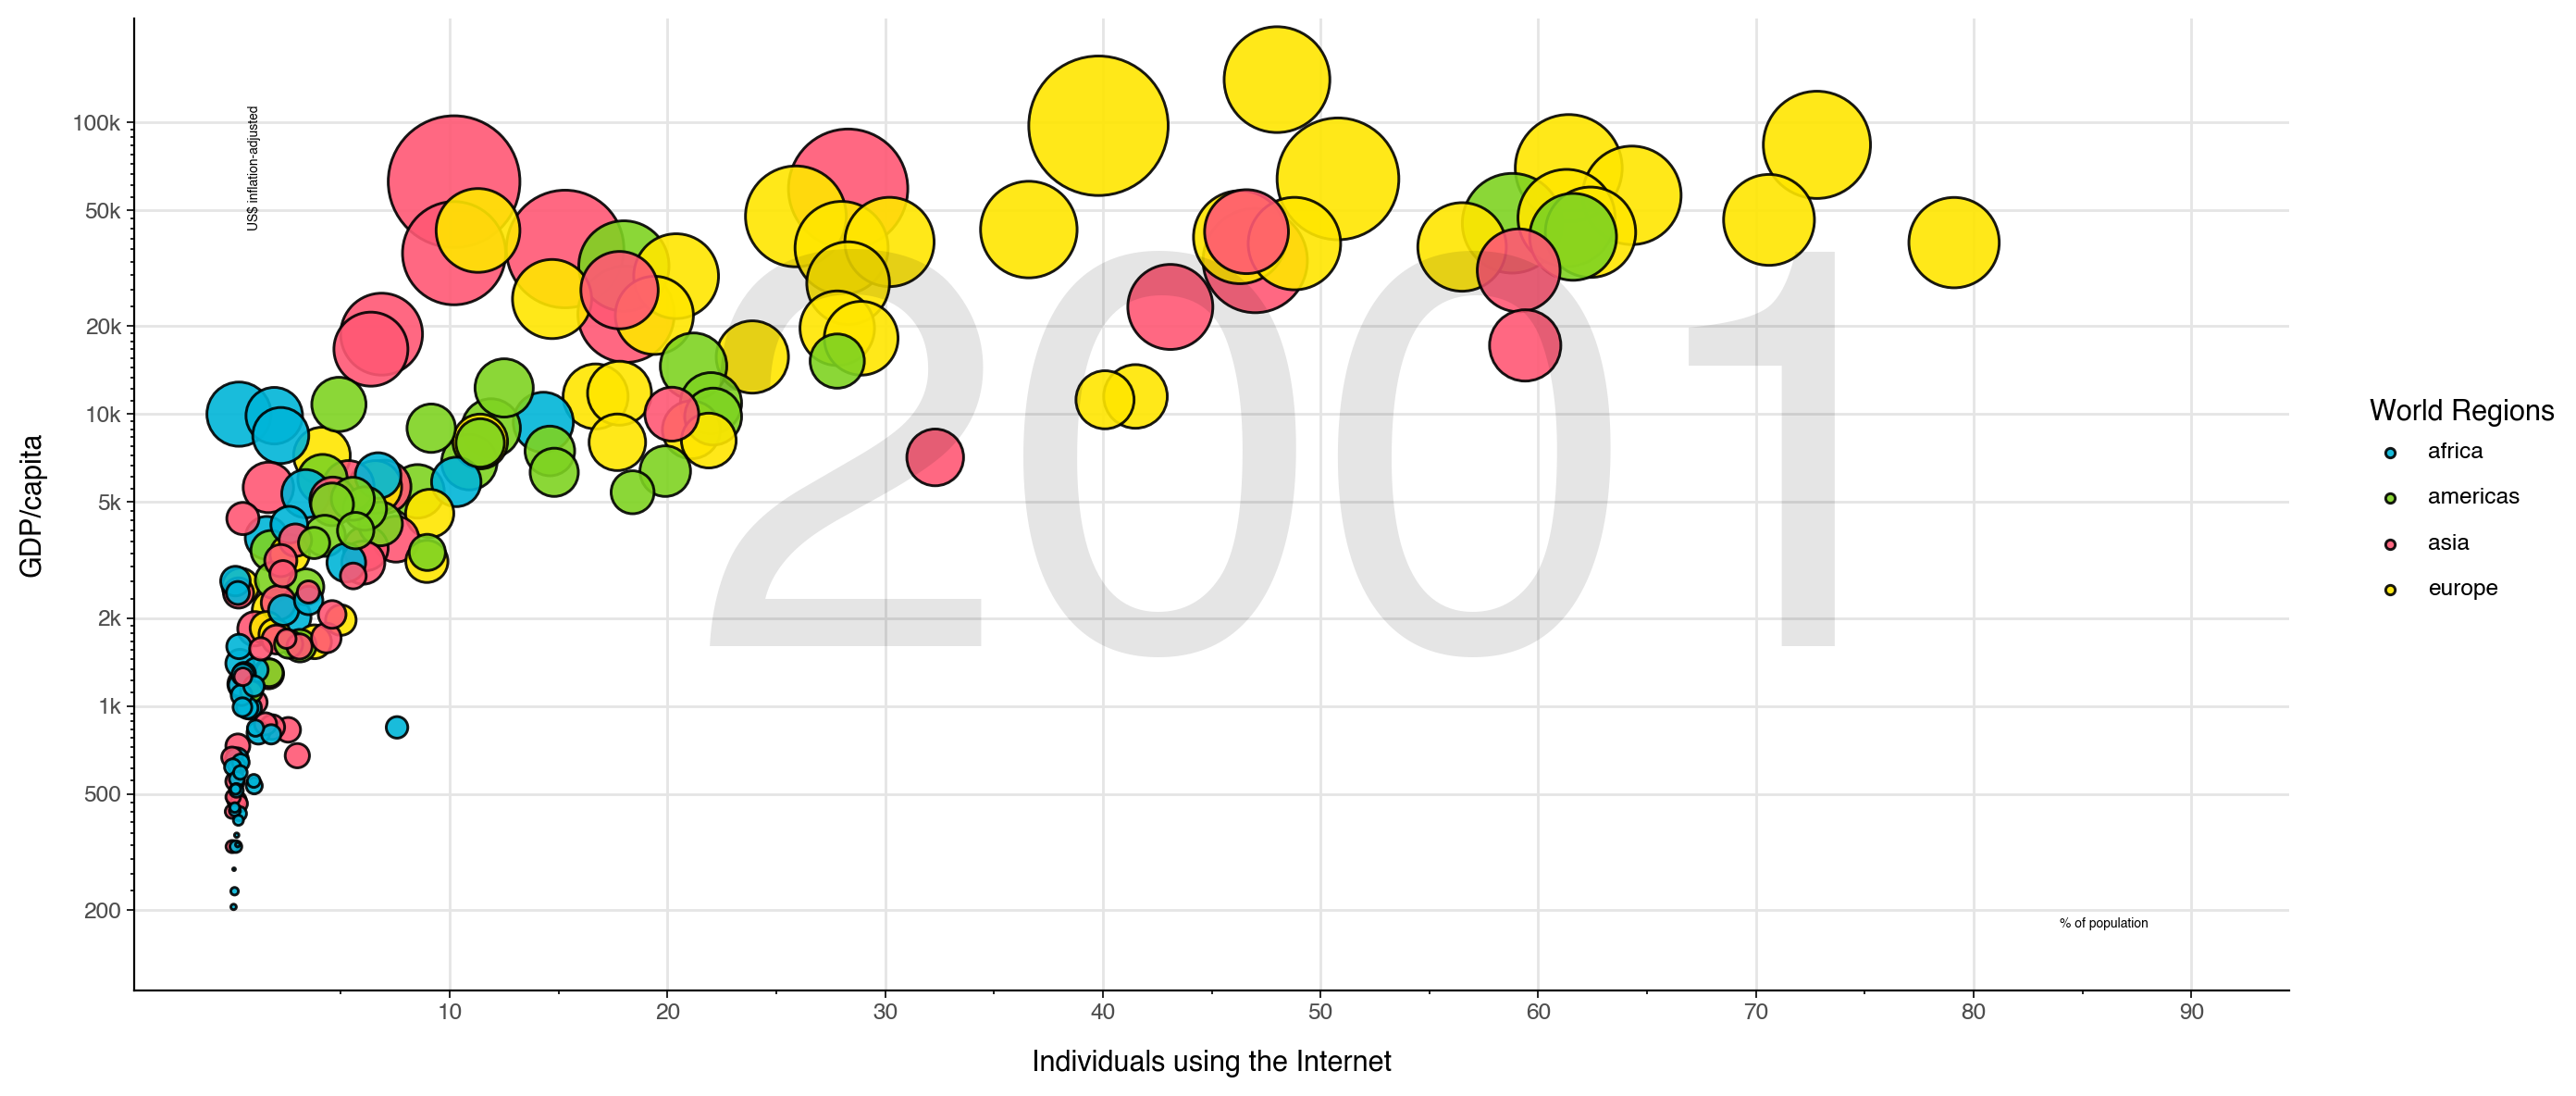

In [ ]:
from plotnine import *

q3_plot = (
    df_Q3
    .dropna(subset=["internet_users", "gdp", "income", "four_regions"])
    .sort_values("income", ascending=False)
    .copy()
)

(
    ggplot(
        q3_plot,
        aes(
            x="internet_users",
            y="gdp",
            size="income",
            fill="four_regions"
        )
    )

    + geom_point(
        shape="o",
        color="black",
        stroke=0.6,
        alpha=0.9
    )

    + scale_x_continuous(
        breaks=[10, 20, 30, 40, 50, 60, 70, 80, 90]
    )

    + scale_y_log10(
        breaks=[
            200,
            500,
            1000,
            2000,
            5000,
            10000,
            20000,
            50000,
            100000
        ],
        labels=[
            "200",
            "500",
            "1k",
            "2k",
            "5k",
            "10k",
            "20k",
            "50k",
            "100k"
        ]
    )

    + coord_cartesian(
        xlim=(0, 90),
        ylim=(150, 160000)
    )

    + scale_fill_manual(
        name="World Regions",
        values={
            "africa": "#00B5D8",
            "americas": "#7ED321",
            "asia": "#FF5874",
            "europe": "#FFE600"})

    + scale_size_area(
        max_size=30,
        guide=None)

    + annotate(
        "text",
        x=50,
        y=5000,
        label="2001",
        size=220,
        alpha=0.10)

    + annotate(
        "text",
        x=86,
        y=180,
        label="% of population",
        size=5 )

    + annotate(
        "text",
        x=1,
        y=70000,
        label="US$ inflation-adjusted",
        angle=90,
        size=5)

    + labs(
        x="Individuals using the Internet",
        y="GDP/capita")

    + theme_minimal()

    + theme(
        figure_size=(14, 6),
        panel_grid_minor=element_blank(),
        axis_line=element_line(
            color="black",
            size=0.8),
        axis_ticks=element_line(
            color="black",
            size=0.6)))

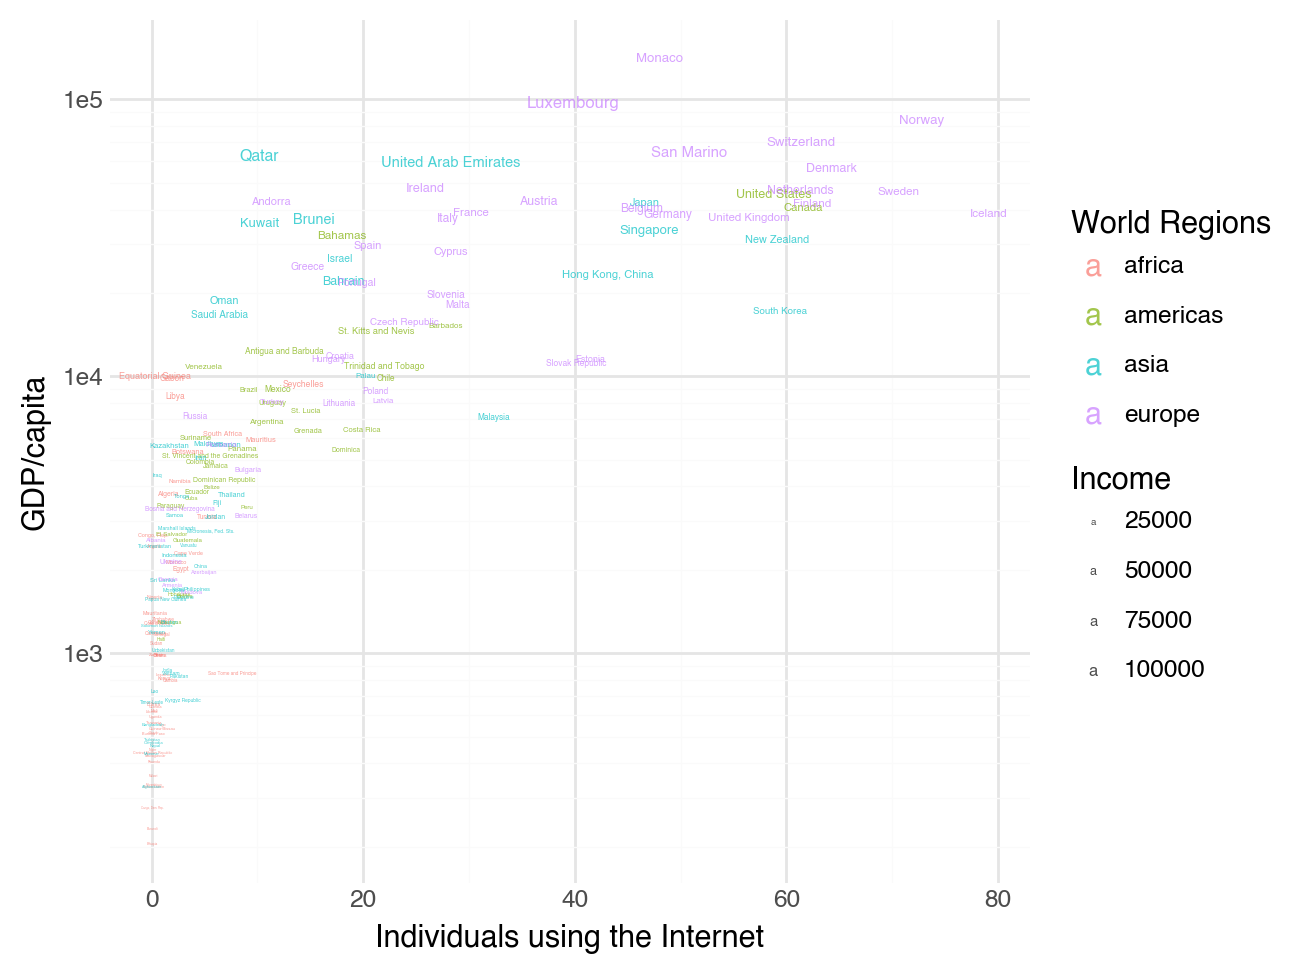

In [72]:
(
    ggplot(
        q3_plot,
        aes(
            x="internet_users",
            y="gdp",
            color="four_regions",
            size="income",
            label="country"
        )
    )
    + geom_text(alpha=0.7)
    + scale_y_log10()
    + labs(
        x="Individuals using the Internet",
        y="GDP/capita",
        color="World Regions",
        size="Income"
    )
    + theme_minimal()
)

This alternative uses country names instead of points. It still shows internet use, GDP per capita, income, and world region. However, many country names overlap, especially for countries with lower internet use and GDP. This makes the graph crowded and difficult to read, so the bubble chart is a better choice for this data.